In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import normalize

In [9]:
im_path = "/data/datasets/nii/BTCV/imagesTr/img0001.nii.gz"
gt_path = "/data/datasets/nii/BTCV/labelsTr/img0001.nii.gz"
im = nib.load(im_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

In [19]:
im.shape, gt.shape

(torch.Size([512, 512, 147]), (512, 512, 147))

In [10]:
scale = 255
im = torch.Tensor(im)
im = (im - im.min()) / (im.max() - im.min()) * scale
# im = im.permute(2,0,1).unsqueeze(1).repeat(1,3,1,1)
# im = normalize(
#     im, 
#     mean=[0.485 * scale, 0.456 * scale, 0.406 * scale],
#     std=[0.229 * scale, 0.224 * scale, 0.225 * scale]
# )
# im = im * 255
# im = im.permute(0, 2, 3, 1)

In [11]:
im.min(), im.max()

(tensor(0.), tensor(255.))

In [12]:
np.unique(gt)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13.])

In [13]:
gt[gt != 1] = 0
gt[gt == 1] = 1

In [14]:
np.argwhere(gt.sum(axis=(0, 1))).squeeze()

array([106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140])

In [16]:
im.shape, gt.shape

(torch.Size([512, 512, 147]), (512, 512, 147))

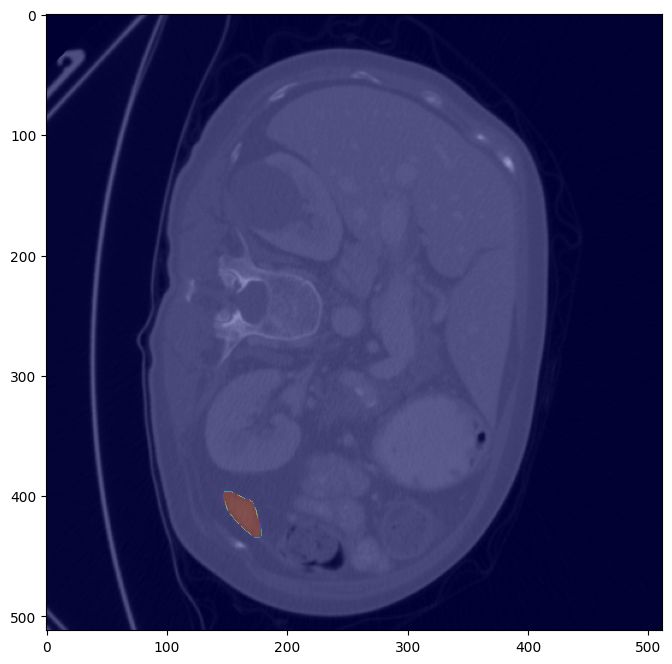

In [18]:
plt.figure(figsize=(8,8))
plt.imshow(im[:, :, 106], cmap="grey")
plt.imshow(gt[:, :, 106], alpha=0.4, cmap="jet")